<a href="https://colab.research.google.com/github/MarioViniciusBC/regressao_linear/blob/main/Exerc%C3%ADcio_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício 4.1

Você é um cientista de dados em uma empresa de aluguel de bicicletas que busca entender a relação entre a temperatura média diária e o número de bicicletas alugadas. A empresa coletou dados ao longo de vários dias e precisa de sua expertise para analisar como a temperatura afeta o aluguel diário de bicicletas.

Utilizar regressão linear para
prever o número de bicicletas
alugadas com base na
temperatura média diária.

Você dispõe de um conjunto de
dados que contém as
seguintes informações:
– Temperatura média diária (em
graus Celsius).
– Número total de bicicletas
alugadas nesse dia.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
dados = pd.read_csv('/content/4.1 - dados_bicicletas.csv') # DataFrame
dados

,Temperatura_Media,Bicicletas_Alugadas
0,10.000000,109.934283
1,10.202020,100.265017
2,10.404040,119.014377
3,10.606061,139.551506
4,10.808081,107.438145
...,...,...
95,29.191919,358.608489
96,29.393939,396.831496
97,29.595960,399.160499
98,29.797980,397.071966


In [7]:
temperatura = dados['Temperatura_Media'].values.reshape(-1, 1)
bicicletas_alugadas = dados['Bicicletas_Alugadas'].values.reshape(-1, 1)

* `df['nome_coluna']`: Seleciona a coluna do  DataFrame (retorno é um Pandas Series).

* `.values`: Extrai os números brutos dessa **Series** e os converte para um array unidimensional (1D) do NumPy.

* `reshape(-1, 1)`: O método **reshape** reorganiza o array 1D em um array 2D. O número -1 diz ao NumPy: "Descubra e calcule automaticamente o número de linhas necessário para acomodar todos os dados, garantindo que tudo fique em apenas 1 coluna".


In [9]:
# Matriz X com o termo de bias incluído
X_b = np.c_[np.ones((len(temperatura), 1)), temperatura]

In [10]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(bicicletas_alugadas)

<sub>A letra **X** (maiúscula) é o padrão matemático universal na estatística e no Machine Learning para representar a matriz de features (os dados de entrada brutos). O sufixo **_b** vem da palavra em inglês **bias** (que traduzimos como viés ou, no contexto de uma regressão, o intercepto). Portanto, **X_b** é apenas uma convenção de nomenclatura muito comum na comunidade de ciência de dados que significa, literalmente: "Matriz X com o termo de bias incluído".</sub>

### $Y = X \cdot \theta$, a equação da previsão

O objetivo da regressão Linear é encontrar a melhor reta para realizar previssões. A equação clássica da reta é:

$$y = \theta_0 + \theta_1 x$$

Onde:
* $\theta_0$ é o **intercepto**.
* $\theta_1$ é o **peso**.

O método dos mínimos quadrados calcula esses coeficientes ($\theta_0$ e $\theta_1$) de uma vez. A operação matricial que o modelo faz para gerar as previsões é $Y = X \cdot \theta$, onde $\theta$ é o vetor de pesos (vetor coluna com os valores que o modelo aprendeu) e $X$, a matriz dos dados. Se fosse passado apenas a coluna de temperatura, a equação que ele tentaria resolver seria $y = \theta_1 x$ (sem o $\theta_0$).

Para resolver isso, adicionamos uma feature falsa que sempre vale $1$ (representando $x_0 = 1$). Assim, quando o algoritmo de Álgebra Linear for multiplicar a matriz de dados ($X$) pelo vetor de pesos ($\theta$), a multiplicação linha por coluna encaixa perfeitamente na fórmula da reta:$$y = (\theta_0 \cdot 1) + (\theta_1 \cdot x)$$

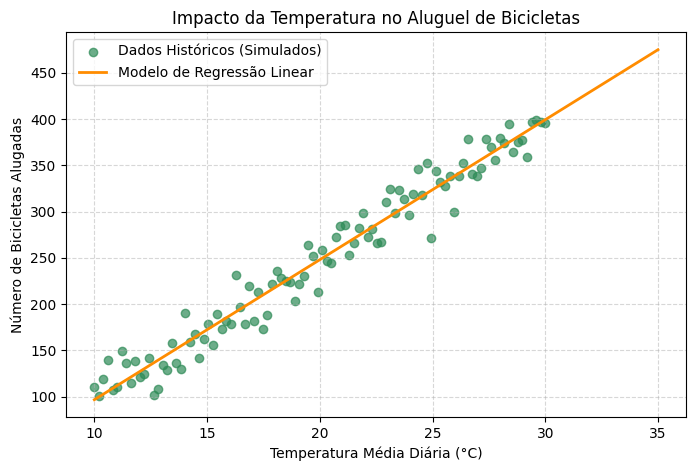

In [11]:
# Passo 3: Visualização dos Dados e do Ajuste Linear
plt.figure(figsize=(8, 5))
plt.scatter(temperatura, bicicletas_alugadas, color='seagreen', alpha=0.7, label='Dados Históricos (Simulados)')

# Criando a reta de regressão usando os coeficientes encontrados
line_x = np.linspace(10, 35, 100).reshape(100, 1)
line_y = theta_best[0] + theta_best[1] * line_x

plt.plot(line_x, line_y, color='darkorange', linewidth=2, label='Modelo de Regressão Linear')
plt.xlabel('Temperatura Média Diária (°C)')
plt.ylabel('Número de Bicicletas Alugadas')
plt.title('Impacto da Temperatura no Aluguel de Bicicletas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [12]:
# Passo 4: Predição (Ajudando a empresa a se planejar)
# Vamos prever a demanda para dias com 15°C, 25°C e 35°C
X_new = np.array([[15], [25], [35]])
X_new_b = np.c_[np.ones((3, 1)), X_new]
alugueis_previstos = X_new_b.dot(theta_best)
alugueis_previstos

array([[172.23340629],
       [323.61273302],
       [474.99205975]])